# Mini-Project 5: Taxi Route Revenue, Pricing & Fleet Planner

**Scenario.** A matatu (14-seater taxi) association runs three routes out of Kampala. It wants to forecast demand, understand its fares, and decide how many vehicles to deploy.

**My approach** (`src/taxi.py`, reusing `src/common/`):
* `Route`: passengers + fare → revenue and descriptive statistics.
* `MarketEquilibrium`: supply and demand as a 2×2 linear system.
* Forecasters, all subclasses of the **same abstract `Forecaster`** used in Mini-Project 1: `MovingAverageForecaster` (the original method), `SimpleExponentialSmoothing`, the shared `LinearTrendForecaster`, and `SeasonalNaiveForecaster` (extension).
* Walk-forward backtesting (`walk_forward` in `src/common/forecasting.py`) and a `FleetPlanner`.

**Assumptions.** Daily counts are total passengers per route per day, both directions combined. The fare is flat per passenger. The Entebbe and Mukono figures are *illustrative*, as stated in the brief. Days are numbered 1–10 as in the brief.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.common.forecasting import LinearTrendForecaster, walk_forward
from src.common.metrics import mae
from src.taxi import (FleetPlanner, MarketEquilibrium, MovingAverageForecaster, Route,
                      SeasonalNaiveForecaster, SimpleExponentialSmoothing, backtest_mae,
                      simulate_weekly_demand, tune_alpha)

SIM_SEED = 11
FIRST_TARGET = 3          # 0-based index 3 = day 4, so the backtest covers days 4-10
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## Task 1: The `Route` class

In [2]:
routes = [
    Route("Kampala-Ntinda",  [35, 40, 42, 50, 55, 60, 48, 52, 47, 45], fare=2_000),
    Route("Kampala-Entebbe", [60, 58, 65, 70, 72, 80, 75, 68, 66, 64], fare=5_000),
    Route("Kampala-Mukono",  [45, 47, 50, 49, 55, 62, 58, 53, 51, 50], fare=3_000),
]
DAYS = np.arange(1, 11)
desc = pd.DataFrame([{**{"route": r.name, "fare (UGX)": r.fare}, **r.describe(),
                      "CV": r.describe()["stdev"] / r.describe()["mean"],
                      "total revenue (UGX)": r.total_revenue(),
                      "mean daily revenue (UGX)": r.daily_revenue().mean()} for r in routes]).set_index("route")
for r in routes:
    print(repr(r))
desc

Route('Kampala-Ntinda', days=10, fare=UGX 2,000)
Route('Kampala-Entebbe', days=10, fare=UGX 5,000)
Route('Kampala-Mukono', days=10, fare=UGX 3,000)


,fare (UGX),mean,variance,stdev,CV,total revenue (UGX),mean daily revenue (UGX)
route,,,,,,,
Kampala-Ntinda,"2,000.00",47.40,54.27,7.37,0.16,"948,000.00","94,800.00"
Kampala-Entebbe,"5,000.00",67.80,45.07,6.71,0.10,"3,390,000.00","339,000.00"
Kampala-Mukono,"3,000.00",52.00,26.44,5.14,0.10,"1,560,000.00","156,000.00"


In [3]:
# Hand check for Ntinda: total = 474 passengers x 2,000
print(sum([35, 40, 42, 50, 55, 60, 48, 52, 47, 45]), "passengers ->", 474 * 2000, "UGX")

474 passengers -> 948000 UGX


Entebbe earns the most (UGX 3.4 m over 10 days) because of its higher fare and higher demand. Ntinda has the most volatile demand (highest CV), which matters for forecasting.

## Task 2: Supply–demand equilibrium on the Ntinda route

Demand Q_d = 120 − 0.02P and supply Q_s = 10 + 0.03P. At equilibrium Q_d = Q_s = Q. Moving the unknowns (Q, P) to the left gives a linear system:

$$\begin{bmatrix}1 & 0.02\\ 1 & -0.03\end{bmatrix}\begin{bmatrix}Q\\ P\end{bmatrix} = \begin{bmatrix}120\\ 10\end{bmatrix}$$

In [4]:
market = MarketEquilibrium(demand_intercept=120, demand_slope=0.02, supply_intercept=10, supply_slope=0.03)
A, b = market.system()
print("A =", A.tolist(), " b =", b.tolist())
p_star, q_star = market.solve()
print(f"Equilibrium: P* = UGX {p_star:,.0f},  Q* = {q_star:.0f} passengers per trip-hour")
print(f"Hand check: 120 - 10 = (0.02 + 0.03) P  ->  P = 110 / 0.05 = {110 / 0.05:,.0f}")

P_now = 2_000
qd, qs = market.quantity_demanded(P_now), market.quantity_supplied(P_now)
print(f"\nAt the current fare UGX {P_now:,}: demand = {qd:.0f}, supply = {qs:.0f} "
      f"-> excess demand of {qd - qs:.0f} passengers per trip-hour; fare is {market.position(P_now)} equilibrium")

A = [[1.0, 0.02], [1.0, -0.03]]  b = [120, 10]
Equilibrium: P* = UGX 2,200,  Q* = 76 passengers per trip-hour
Hand check: 120 - 10 = (0.02 + 0.03) P  ->  P = 110 / 0.05 = 2,200

At the current fare UGX 2,000: demand = 80, supply = 70 -> excess demand of 10 passengers per trip-hour; fare is below equilibrium


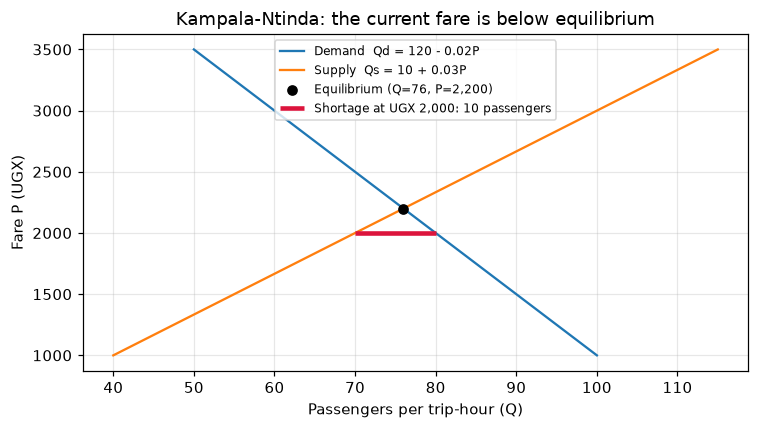

In [5]:
P = np.linspace(1_000, 3_500, 100)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(market.quantity_demanded(P), P, label="Demand  Qd = 120 - 0.02P")
ax.plot(market.quantity_supplied(P), P, label="Supply  Qs = 10 + 0.03P")
ax.scatter([q_star], [p_star], color="black", zorder=3, label=f"Equilibrium (Q={q_star:.0f}, P={p_star:,.0f})")
ax.hlines(P_now, qs, qd, color="crimson", lw=3, label=f"Shortage at UGX {P_now:,}: {qd - qs:.0f} passengers")
ax.set_xlabel("Passengers per trip-hour (Q)")
ax.set_ylabel("Fare P (UGX)")
ax.set_title("Kampala-Ntinda: the current fare is below equilibrium")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("figures/p5_equilibrium.png", bbox_inches="tight")
plt.show()

**Interpretation.** The market-clearing fare is **UGX 2,200**, at which 76 passengers per trip-hour want to travel and operators want to carry 76. The current **UGX 2,000 is UGX 200 (9 %) below equilibrium**. At that price passengers want 80 seats per trip-hour but operators supply only 70, a **shortage of 10 passengers per trip-hour**. In practice this shows up as queues at the stage, overloading, or informal peak-hour fare hikes (common on Kampala routes when it rains or at rush hour).

Two responses are available. The association could raise the fare towards UGX 2,200, which clears the queue but prices out about 4 passengers per trip-hour. Or it could keep the fare and **add supply** (more vehicles at peak hours), which serves more people but at a margin operators find less attractive. A caveat: these curves are given, not estimated. Their units (passengers per *trip-hour*) do not match the daily counts above, so the two parts of this project cannot be linked quantitatively.

## Task 3: Forecasters

| Class | Forecast for the next day | Parameters |
|---|---|---|
| `MovingAverageForecaster(3)` | mean of the last 3 days (original method) | window |
| `SimpleExponentialSmoothing(α)` | level ℓ_t = α y_t + (1 − α) ℓ_{t−1}, with ℓ_0 = y_1 | α ∈ (0, 1] |
| `LinearTrendForecaster` | OLS line through all past days, extrapolated (shared with Mini-Project 1) | slope and intercept |

All three are subclasses of `Forecaster`, so the backtesting code works with any of them unchanged (polymorphism).

## Task 4: Walk-forward backtesting (days 4–10) and α tuning

**Rolling origin:** to forecast day *t*, each model is fitted only on days 1 … t − 1, then the origin moves forward one day. Day 4 is the first target because the 3-day moving average needs three days of history. Each route gives 7 one-step-ahead forecasts, scored by MAE.

In [6]:
alpha_grid = np.round(np.arange(0.05, 1.0001, 0.05), 2)
alpha_curves, best_alpha, results = {}, {}, []
for r in routes:
    alpha_curves[r.name] = [backtest_mae(SimpleExponentialSmoothing(a), r.passengers, FIRST_TARGET) for a in alpha_grid]
    a_best, _ = tune_alpha(r.passengers, alpha_grid, FIRST_TARGET)
    best_alpha[r.name] = a_best
    for model in [MovingAverageForecaster(3), SimpleExponentialSmoothing(a_best), LinearTrendForecaster()]:
        results.append({"route": r.name, "model": model.name,
                        "MAE (passengers)": backtest_mae(model, r.passengers, FIRST_TARGET),
                        "MAE (UGX revenue)": backtest_mae(model, r.passengers, FIRST_TARGET) * r.fare})
mae_table = pd.DataFrame(results)
mae_pivot = mae_table.pivot(index="model", columns="route", values="MAE (passengers)")
print("Best alpha per route:", best_alpha)
mae_pivot

Best alpha per route: {'Kampala-Ntinda': 1.0, 'Kampala-Entebbe': 1.0, 'Kampala-Mukono': 1.0}


route,Kampala-Entebbe,Kampala-Mukono,Kampala-Ntinda
model,,,
3-day moving average,7.19,5.33,7.52
Linear trend,7.71,6.39,7.87
SES (alpha=1.00),4.43,3.71,5.86


In [7]:
# Hand check: MA(3) on Ntinda, first target day 4 = mean(35, 40, 42) = 39 vs actual 50 -> error 11
ntinda = routes[0].passengers
ma_preds = walk_forward(MovingAverageForecaster(3), ntinda, FIRST_TARGET)
print("MA(3) walk-forward predictions, Ntinda:", ma_preds.round(2))
print("first prediction by hand:", np.mean([35, 40, 42]))
print("MAE by hand:", np.mean(np.abs(ntinda[3:] - ma_preds)).round(3))

MA(3) walk-forward predictions, Ntinda: [39.   44.   49.   55.   54.33 53.33 49.  ]
first prediction by hand: 39.0
MAE by hand: 7.524


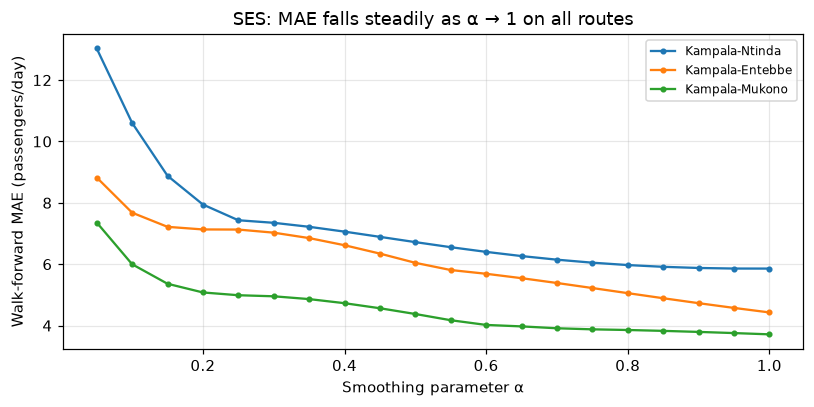

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for name, curve in alpha_curves.items():
    ax.plot(alpha_grid, curve, marker=".", label=name)
ax.set_xlabel("Smoothing parameter α")
ax.set_ylabel("Walk-forward MAE (passengers/day)")
ax.set_title("SES: MAE falls steadily as α → 1 on all routes")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Results.**
* **SES has the lowest MAE on every route, and the grid search picks α = 1.0 every time.** With α = 1, SES reduces to the **naïve forecast** ("tomorrow = today"). On these short series, demand behaves more like a random walk than noise around a stable level, so the most recent day is the best guide and averaging in older days only adds lag.
* The **3-day moving average** (the original method) lags behind changes: it under-forecasts during the rise to day 6 and over-forecasts during the fall afterwards.
* The **linear trend** is worst. It extrapolates the early rise (days 1–6) into a fall that never comes.

**Caveat about tuning.** α was chosen on the same 7 days on which it is scored. That makes the SES result slightly optimistic: it is an *in-sample* tuned score. With more data I would tune α on an earlier window and evaluate on a later one (nested walk-forward). The MAE curves flatten for α ≥ 0.8 on Ntinda and Mukono (any high α performs about the same there), while Entebbe keeps improving right up to α = 1.

## Task 5: Day-11 revenue forecast with the best model

In [9]:
best_model_name = mae_table.loc[mae_table.groupby("route")["MAE (passengers)"].idxmin()].set_index("route")["model"]
MODEL_FACTORY = {
    "3-day moving average": lambda r: MovingAverageForecaster(3),
    "Linear trend": lambda r: LinearTrendForecaster(),
}
def best_model_for(route):
    name = best_model_name[route.name]
    return MODEL_FACTORY[name](route) if name in MODEL_FACTORY else SimpleExponentialSmoothing(best_alpha[route.name])

day11 = []
for r in routes:
    model = best_model_for(r)
    pax = model.fit(r.passengers).predict(1)[0]
    day11.append({"route": r.name, "best model": model.name, "day-11 passengers": pax,
                  "day-11 revenue (UGX)": pax * r.fare,
                  "backtest MAE (UGX)": backtest_mae(model, r.passengers, FIRST_TARGET) * r.fare})
day11 = pd.DataFrame(day11).set_index("route")
day11

,best model,day-11 passengers,day-11 revenue (UGX),backtest MAE (UGX)
route,,,,
Kampala-Ntinda,SES (alpha=1.00),45.00,"90,000.00","11,714.29"
Kampala-Entebbe,SES (alpha=1.00),64.00,"320,000.00","22,142.86"
Kampala-Mukono,SES (alpha=1.00),50.00,"150,000.00","11,142.86"


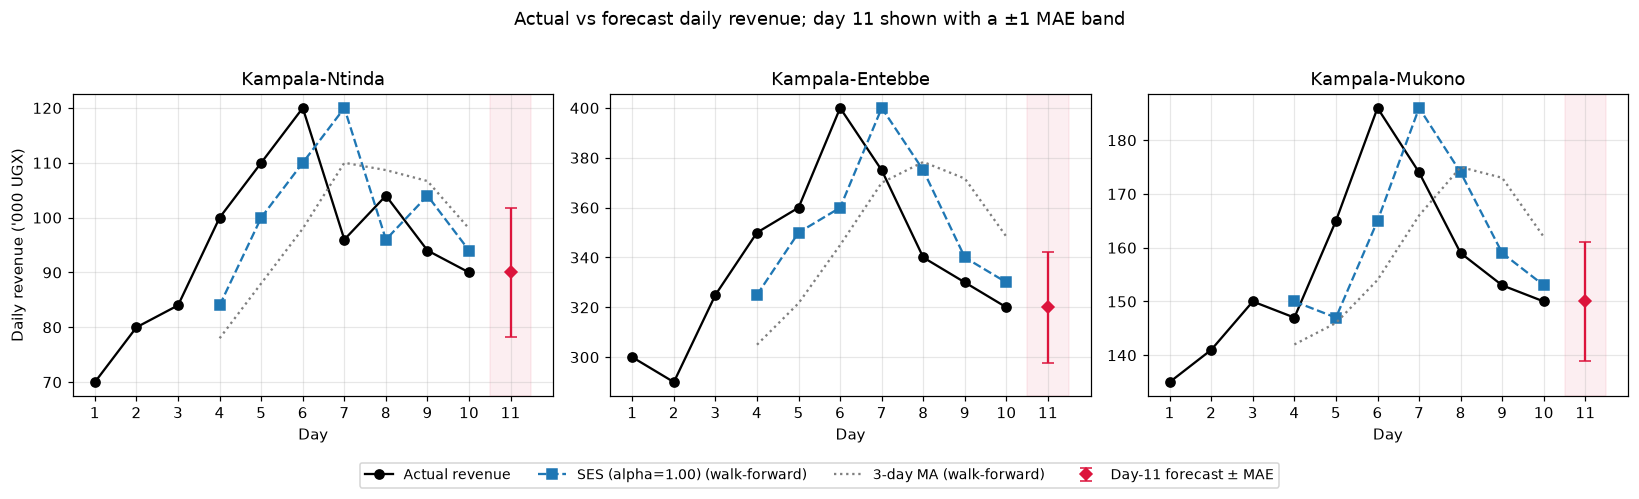

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, r in zip(axes, routes):
    model = best_model_for(r)
    wf = walk_forward(model, r.passengers, FIRST_TARGET) * r.fare
    ma = walk_forward(MovingAverageForecaster(3), r.passengers, FIRST_TARGET) * r.fare
    ax.plot(DAYS, r.daily_revenue() / 1e3, "ko-", label="Actual revenue")
    ax.plot(DAYS[FIRST_TARGET:], wf / 1e3, "s--", color="tab:blue", label=f"{model.name} (walk-forward)")
    ax.plot(DAYS[FIRST_TARGET:], ma / 1e3, ":", color="tab:grey", label="3-day MA (walk-forward)")
    f11 = day11.loc[r.name, "day-11 revenue (UGX)"] / 1e3
    err = day11.loc[r.name, "backtest MAE (UGX)"] / 1e3
    ax.errorbar([11], [f11], yerr=[[err], [err]], fmt="D", color="crimson", capsize=4, label="Day-11 forecast ± MAE")
    ax.axvspan(10.5, 11.5, color="crimson", alpha=0.07)
    ax.set_title(r.name)
    ax.set_xlabel("Day")
    ax.set_xticks(range(1, 12))
axes[0].set_ylabel("Daily revenue ('000 UGX)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.08))
fig.suptitle("Actual vs forecast daily revenue; day 11 shown with a ±1 MAE band", y=1.02)
fig.tight_layout()
fig.savefig("figures/p5_revenue_forecast.png", bbox_inches="tight")
plt.show()

## Task 6: Fleet planning for day 11

Capacity per vehicle = 8 one-way trips × 14 seats = **112 passengers/day**.
Vehicles = ⌈ forecast × 1.15 / 112 ⌉. I round **up**, because rounding down guarantees that some passengers are left at the stage on a busy day. I also check a "busy day" scenario (forecast + one MAE) to see whether the answer is robust.

In [11]:
fleet = FleetPlanner(trips_per_vehicle=8, seats=14, buffer=0.15)
plan = []
for r in routes:
    f = day11.loc[r.name, "day-11 passengers"]
    busy = f + day11.loc[r.name, "backtest MAE (UGX)"] / r.fare
    plan.append({"route": r.name, "forecast passengers": f, "with 15% buffer": f * 1.15,
                 "exact vehicles": f * 1.15 / fleet.capacity_per_vehicle,
                 "vehicles (rounded up)": fleet.vehicles_needed(f),
                 "vehicles, busy day (+1 MAE)": fleet.vehicles_needed(busy),
                 "seat utilisation": f / (fleet.vehicles_needed(f) * fleet.capacity_per_vehicle),
                 "max passengers in 10 days": r.passengers.max(),
                 "vehicles for max day": fleet.vehicles_needed(r.passengers.max())})
fleet_table = pd.DataFrame(plan).set_index("route")
print(fleet)
fleet_table

FleetPlanner(trips=8, seats=14, buffer=15%)


,forecast passengers,with 15% buffer,exact vehicles,vehicles (rounded up),"vehicles, busy day (+1 MAE)",seat utilisation,max passengers in 10 days,vehicles for max day
route,,,,,,,,
Kampala-Ntinda,45.00,51.75,0.46,1,1,0.40,60.00,1
Kampala-Entebbe,64.00,73.60,0.66,1,1,0.57,80.00,1
Kampala-Mukono,50.00,57.50,0.51,1,1,0.45,62.00,1


**Recommendation: one vehicle per route on day 11.** Even with the 15 % buffer, a "busy" day, or the busiest of the last 10 days, demand stays below the 112 seats a single vehicle offers. The vehicle would run at about 40–60 % seat utilisation, so the association has spare capacity. It could cut trips (e.g. 6 instead of 8 on Ntinda) or move the vehicle to peak hours, where the Task 2 shortage is felt.

Realistically, real Kampala routes carry thousands of passengers a day, so these counts are probably a *sample* (e.g. one stage or one vehicle). The planning rule (`FleetPlanner`) still applies unchanged if the true counts are supplied.

## Extension: 60 days with a weekly pattern, seasonal-naïve vs moving average

I simulate 60 days (seed 11), starting on a Monday, with base demand of 50 passengers × weekday multipliers (Mon 1.00, Tue 0.95, Wed 1.00, Thu 1.05, **Fri 1.35**, Sat 1.10, **Sun 0.60**) plus noise σ = 3. Both models are walk-forward backtested from day 15 to day 60, so every seasonal-naïve forecast has at least two weeks of history.

In [12]:
y60 = simulate_weekly_demand(days=60, base=50, seed=SIM_SEED, noise_sd=3)
start = 14
models60 = [SeasonalNaiveForecaster(7), MovingAverageForecaster(3), MovingAverageForecaster(7),
            SimpleExponentialSmoothing(tune_alpha(y60, first_target=start)[0])]
ext = pd.DataFrame({"model": [m.name for m in models60],
                    "walk-forward MAE (passengers)": [backtest_mae(m, y60, start) for m in models60]}
                   ).sort_values("walk-forward MAE (passengers)").set_index("model")
ext

,walk-forward MAE (passengers)
model,
Seasonal naive (period=7),2.91
7-day moving average,7.07
SES (alpha=0.05),7.11
3-day moving average,8.46


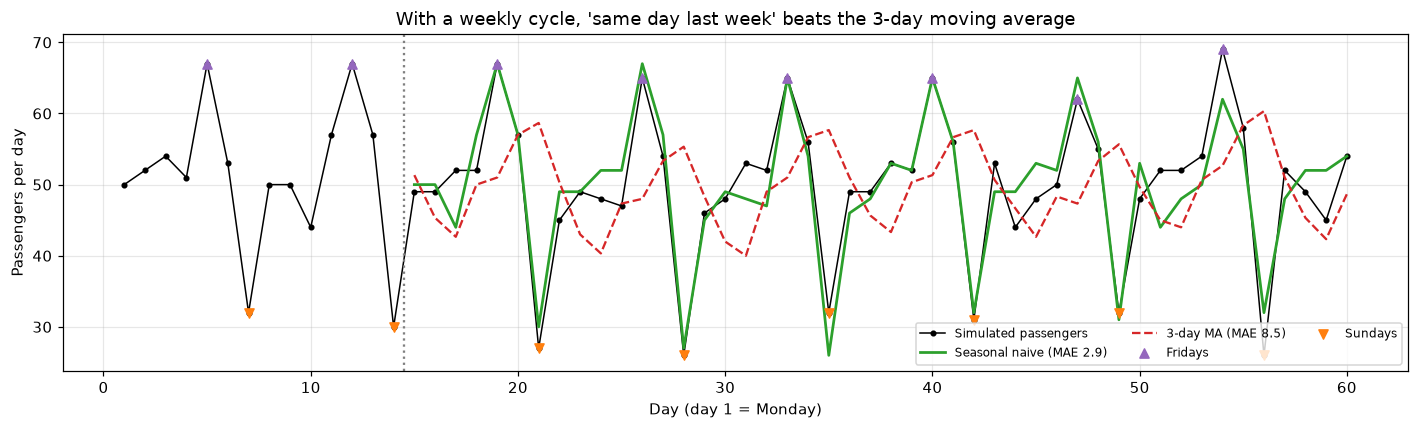

In [13]:
days60 = np.arange(1, 61)
sn = walk_forward(SeasonalNaiveForecaster(7), y60, start)
ma3 = walk_forward(MovingAverageForecaster(3), y60, start)
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(days60, y60, "k.-", lw=1, label="Simulated passengers")
ax.plot(days60[start:], sn, color="tab:green", lw=1.8, label=f"Seasonal naive (MAE {mae(y60[start:], sn):.1f})")
ax.plot(days60[start:], ma3, color="tab:red", lw=1.5, ls="--", label=f"3-day MA (MAE {mae(y60[start:], ma3):.1f})")
fridays = days60[4::7]; sundays = days60[6::7]
ax.scatter(fridays, y60[4::7], marker="^", color="tab:purple", zorder=3, label="Fridays")
ax.scatter(sundays, y60[6::7], marker="v", color="tab:orange", zorder=3, label="Sundays")
ax.axvline(start + 0.5, color="grey", ls=":")
ax.set_xlabel("Day (day 1 = Monday)")
ax.set_ylabel("Passengers per day")
ax.set_title("With a weekly cycle, 'same day last week' beats the 3-day moving average")
ax.legend(fontsize=8, ncol=3)
fig.tight_layout()
fig.savefig("figures/p5_seasonal_extension.png", bbox_inches="tight")
plt.show()

**Why seasonal-naïve wins.** The 3-day moving average mixes days of different types. On a Friday it averages Tuesday–Thursday, so it under-forecasts the peak. On Monday it includes the quiet Sunday, so it under-forecasts again. The moving average is always about 1.5 days behind and smears out the cycle, giving errors about three times larger. Seasonal-naïve compares like with like, so its only error is the random noise. The error is the difference of two independent noisy values, so in theory its MAE is about √2·σ·√(2/π) ≈ 3.4 passengers, close to the 2.9 we observe. A 7-day moving average removes the cycle but cannot forecast it; SES behaves similarly. The lesson for the association: before choosing a forecasting model, **plot the data and look for weekly structure**. If it is there, a model that ignores it will lose to the simplest model that respects it.

## Findings & Limitations

**Findings.** Entebbe is the most valuable route (highest fare and demand); Ntinda is the most volatile. On Ntinda, the UGX 2,000 fare sits **9 % below the UGX 2,200 equilibrium**, which creates a shortage of about 10 passengers per trip-hour. That explains queues at peak times and suggests either a modest fare rise or more peak-hour vehicles. For forecasting, simple exponential smoothing won on all routes in walk-forward testing, but only because the tuned α = 1 makes it the naïve "same as yesterday" forecast. The 10-day series are dominated by short-lived swings, so the 3-day moving average (the original method) lags and the linear trend extrapolates a rise that reverses. Day-11 forecasts are 45, 64 and 50 passengers (UGX 90k, 320k and 150k). One vehicle per route is enough, even with a 15 % buffer, at roughly 40–60 % utilisation. The extension shows that once a weekly pattern exists, a seasonal-naïve model clearly beats the moving average.

**Limitations.** Ten days give only seven forecast errors per model, so the model ranking is fragile, and tuning α on the same window inflates the SES score. The daily counts are too small to be a whole route's traffic, and their unit differs from the trip-hour equilibrium model, so pricing and fleet results cannot be combined. The fleet rule ignores peak-hour concentration (most demand falls at morning and evening rush hours), traffic congestion that reduces trips per day, and vehicle breakdowns.